# Benchmark Input Inspection — shared anchor + per-setup probe corpora

Sanity-checks the per-setup eval inputs produced by
[scripts/processing/ripe_atlas/select_probes_and_anchors.py](../scripts/processing/ripe_atlas/select_probes_and_anchors.py):
the **shared anchor corpus** (one set of targets used by every setup) and the
**six per-setup probe corpora** (one VP set per AS under test). Shows the filter
funnel for each and maps the kept points.

Raw probe/anchor exploration (world maps, top-20 ASN bars, anchors by
continent) lives in
[visualize_raw_probes_anchors.ipynb](visualize_raw_probes_anchors.ipynb).

In [1]:
# === Parameters (tagged) ===
PROBES_PATH = "datasets/ripe_atlas/filtered_probes.json"
ANCHORS_PATH = "datasets/ripe_atlas/filtered_anchors.json"

In [2]:
import json
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
print(f"repo root: {ROOT}")

# Put repo root on sys.path so `from scripts.processing.ripe_atlas...` works.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

with open(ROOT / PROBES_PATH) as fh:
    raw_probes = json.load(fh)
with open(ROOT / ANCHORS_PATH) as fh:
    raw_anchors = json.load(fh)

# `all_df` = the full sanitized probe corpus. Used as the faint gray
# background under each per-setup probe map below.
all_rows = []
for e in raw_probes:
    geom = (e.get("geometry") or {}).get("coordinates")
    if not geom or len(geom) < 2:
        continue
    all_rows.append({
        "ip": e.get("address_v4"),
        "lat": float(geom[1]),
        "lon": float(geom[0]),
        "country": e.get("country_code"),
        "asn": e.get("asn_v4"),
    })
all_df = pd.DataFrame(all_rows)
print(f"sanitized probe corpus: {len(all_df):,} probes  |  sanitized anchor corpus: {len(raw_anchors):,}")

repo root: /home/nuwinslab/workspace/atnt/cbg-framework
sanitized probe corpus: 9,229 probes  |  sanitized anchor corpus: 723


## Setup helpers

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_probes_on_map(
    ax,
    lons,
    lats,
    *,
    title=None,
    label=None,
    color="#d62728",
    s=20,
    alpha=0.85,
    gridlines=True,
    background_lons=None,
    background_lats=None,
    title_fontsize=11,
):
    """PlateCarree world-map scatter helper. Background args underplot a faint gray context layer."""
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="#f4f1ea")
    ax.add_feature(cfeature.OCEAN, facecolor="#e8eef5")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#555")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="#888")
    if gridlines:
        ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    if background_lons is not None and background_lats is not None:
        ax.scatter(
            background_lons,
            background_lats,
            s=3,
            c="#bbb",
            alpha=0.25,
            edgecolors="none",
            transform=ccrs.PlateCarree(),
            zorder=2,
        )
    ax.scatter(
        lons,
        lats,
        s=s,
        c=color,
        alpha=alpha,
        edgecolors="none",
        label=label,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )
    if title:
        ax.set_title(title, fontsize=title_fontsize)
    if label:
        ax.legend(loc="lower left", fontsize=9, framealpha=0.85)


# Country-code → name lookup (used in the per-setup funnel table).
with open(ROOT / "datasets/static_datasets/countries.json") as fh:
    _COUNTRIES = json.load(fh)

_COUNTRY_FIXUPS = {
    "US": "United States", "GB": "United Kingdom", "AE": "United Arab Emirates",
    "KR": "South Korea", "KP": "North Korea", "NZ": "New Zealand",
    "HK": "Hong Kong", "MO": "Macau", "PR": "Puerto Rico",
    "DO": "Dominican Republic", "CD": "DR Congo", "CR": "Costa Rica",
    "CI": "Côte d'Ivoire", "BA": "Bosnia and Herzegovina",
    "TT": "Trinidad and Tobago", "SA": "Saudi Arabia", "LK": "Sri Lanka",
    "BF": "Burkina Faso", "PG": "Papua New Guinea",
    "GQ": "Equatorial Guinea", "GW": "Guinea-Bissau",
    "AG": "Antigua and Barbuda", "SV": "El Salvador", "CZ": "Czechia",
    "ST": "São Tomé and Príncipe", "BV": "Bouvet Island",
    "FK": "Falkland Islands", "FM": "Micronesia", "SL": "Sierra Leone",
    "NC": "New Caledonia", "VG": "British Virgin Islands",
    "VI": "U.S. Virgin Islands", "MP": "Northern Mariana Islands",
    "CV": "Cape Verde", "SH": "Saint Helena", "CK": "Cook Islands",
    "MH": "Marshall Islands", "SB": "Solomon Islands",
    "HM": "Heard and McDonald Islands", "TF": "French Southern Territories",
    "TC": "Turks and Caicos", "CC": "Cocos (Keeling) Islands",
    "CX": "Christmas Island", "EH": "Western Sahara",
    "WF": "Wallis and Futuna", "FO": "Faroe Islands", "IM": "Isle of Man",
    "PF": "French Polynesia", "GF": "French Guiana",
    "PM": "Saint Pierre and Miquelon", "SM": "San Marino",
    "KN": "Saint Kitts and Nevis", "LC": "Saint Lucia",
    "VC": "Saint Vincent and the Grenadines",
    "GS": "South Georgia", "AS": "American Samoa",
    "ZA": "South Africa", "CF": "Central African Republic",
}


def country_name(code):
    """ISO 3166-1 alpha-2 → full country name; falls back to the code itself."""
    if not code:
        return ""
    if code in _COUNTRY_FIXUPS:
        return _COUNTRY_FIXUPS[code]
    entry = _COUNTRIES.get(code)
    if not entry:
        return code
    return entry.get("name") or code

## Benchmark inputs: shared anchor corpus

Loads the **shared** anchor eval set produced by
[scripts/processing/ripe_atlas/select_probes_and_anchors.py](../scripts/processing/ripe_atlas/select_probes_and_anchors.py).
The script excludes the *union* of all six setup ASNs from the 723-anchor
sanitized corpus, so every setup evaluates against the same 721 anchors —
apples-to-apples comparison, no institutional-proximity leakage in any
direction. The map below marks the dropped anchors (×) so the methodology
guard is visually traceable.

In [4]:
CORPORA_DIR = ROOT / "datasets/ripe_atlas/asn_corpora"

with open(CORPORA_DIR / "anchors" / "anchors.json") as fh:
    shared_anchors = json.load(fh)
with open(CORPORA_DIR / "anchors" / "anchors_stats.json") as fh:
    shared_anchor_stats = json.load(fh)

print(f"Shared eval anchors: {shared_anchor_stats['kept']:,} "
      f"(from {shared_anchor_stats['input_total']:,} sanitized "
      f"minus {shared_anchor_stats['dropped_same_asn_count']:,} same-ASN "
      f"minus {shared_anchor_stats['dropped_unreachable_count']:,} unreachable)")
print(f"Excluded ASNs: {shared_anchor_stats['excluded_asns']}")
print()

# Per-continent kept counts: cross-check stats `kept_by_continent` against
# the per-record `continent` field that append_geo_info_to_probe_anchor.py
# now writes onto every anchor record.
record_continent_counts = Counter(a.get("continent") or "?" for a in shared_anchors)
stats_continent_counts = shared_anchor_stats["kept_by_continent"]
all_continents = sorted(set(record_continent_counts) | set(stats_continent_counts))
print(f"Kept anchors by continent  ({'records vs stats — match' if dict(record_continent_counts) == dict(stats_continent_counts) else 'records vs stats — MISMATCH'}):")
for cont in all_continents:
    n_rec = record_continent_counts.get(cont, 0)
    n_stats = stats_continent_counts.get(cont, 0)
    marker = "" if n_rec == n_stats else "  ← mismatch"
    print(f"  {cont:<15s} records={n_rec:>3}  stats={n_stats:>3}{marker}")
print()

print(f"Dropped same-ASN anchors ({len(shared_anchor_stats['dropped_same_asn'])}):")
for d in shared_anchor_stats["dropped_same_asn"]:
    operator = shared_anchor_stats["excluded_asn_operators"].get(str(d["asn_v4"]), "?")
    print(f"  id={d['id']:>5}  {d['address_v4']:>16}  AS{d['asn_v4']} ({operator})  cc={d['country_code']}")

Shared eval anchors: 713 (from 723 sanitized minus 2 same-ASN minus 8 unreachable)
Excluded ASNs: [3209, 3215, 7018, 7922, 16509, 31898]

Kept anchors by continent  (records vs stats — match):
  Africa          records= 16  stats= 16
  Asia            records=115  stats=115
  Europe          records=415  stats=415
  North America   records=122  stats=122
  Oceania         records= 18  stats= 18
  South America   records= 27  stats= 27

Dropped same-ASN anchors (2):
  id= 6072     76.26.115.194  AS7922 (Comcast)  cc=US
  id= 6964    68.121.162.125  AS7018 (AT&T)  cc=US


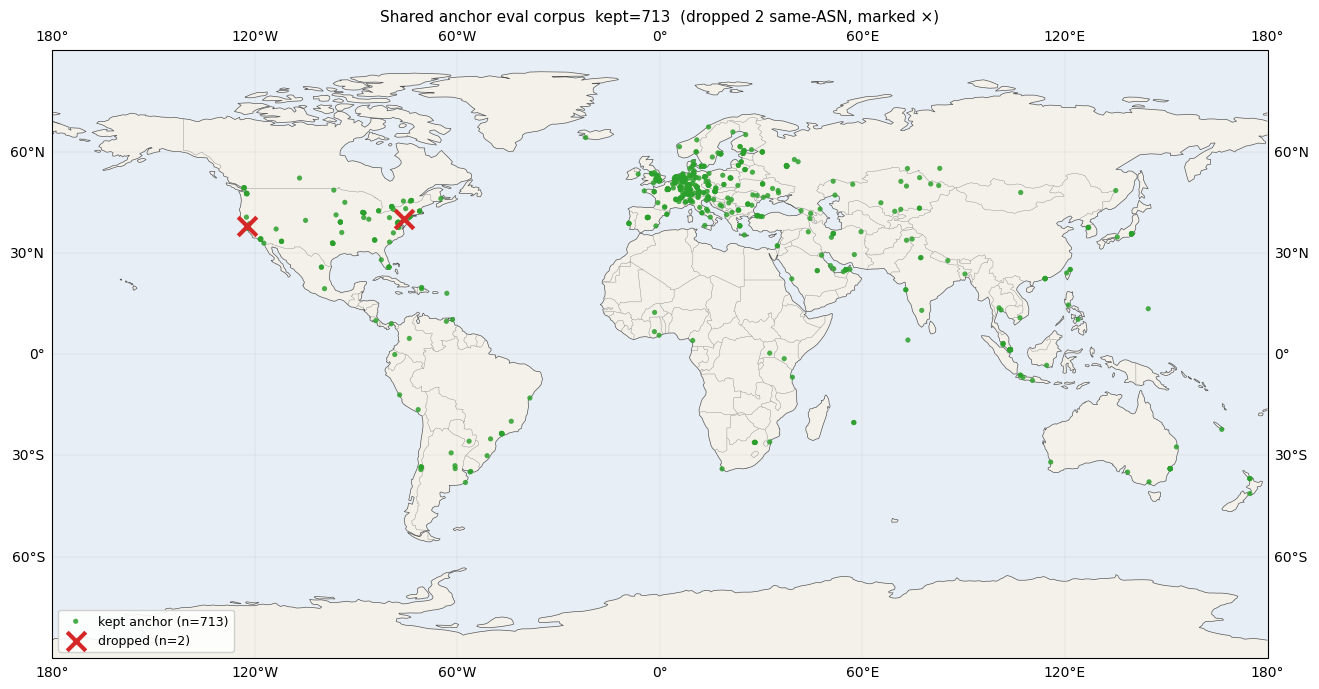

In [5]:
# Plot the 721 shared anchors + mark the 2 dropped ones with red ×.
def _coords(entries):
    lons, lats = [], []
    for e in entries:
        geom = (e.get("geometry") or {}).get("coordinates")
        if not geom or len(geom) < 2:
            continue
        lons.append(float(geom[0]))
        lats.append(float(geom[1]))
    return lons, lats


kept_lons, kept_lats = _coords(shared_anchors)
# Dropped entries are recorded in stats by id; recover their coords from raw_anchors.
dropped_ids = {d["id"] for d in shared_anchor_stats["dropped_same_asn"]}
dropped_full = [a for a in raw_anchors if a.get("id") in dropped_ids]
drop_lons, drop_lats = _coords(dropped_full)

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
plot_probes_on_map(
    ax,
    kept_lons,
    kept_lats,
    title=(
        f"Shared anchor eval corpus  kept={len(kept_lons)}  "
        f"(dropped {len(drop_lons)} same-ASN, marked ×)"
    ),
    label=f"kept anchor (n={len(kept_lons)})",
    color="#2ca02c",
    s=14,
    alpha=0.85,
)
ax.scatter(
    drop_lons, drop_lats,
    s=180, c="#d62728", marker="x", linewidths=3,
    transform=ccrs.PlateCarree(), zorder=5,
    label=f"dropped (n={len(drop_lons)})",
)
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

## Benchmark inputs: per-setup probe corpora

Loads the six per-setup probe JSONs from
[datasets/ripe_atlas/asn_corpora/](../../../datasets/ripe_atlas/asn_corpora/)
and shows the **filter funnel** each setup goes through:

```
matched_asn
  → continent filter   (drop_other_continent + drop_coords_outside_continent
                        + drop_no_country_code + drop_no_coords)
  → CBG mislocation    (drop probes whose stated coords violate
                        speed-of-internet vs anchor RTTs)
  → city dedup         (snap to 0.1° grid, one probe per cell)
  → kept
```

The CBG mislocation step is the newest guard (commit `0d0e413`); the
`cbg_mislocation_filter` block in each `*_stats.json` carries the speed
ratio and RTT bound used, which we print once below since they're
constant across all setups.

In [ ]:
# Same six setups as select_probes_and_anchors.py, in display order.
SETUPS = [
    (7922,  "Comcast",      "North America", "north_america"),
    (7018,  "AT&T",         "North America", "north_america"),
    (3209,  "Vodafone DE",  "Europe",        "europe"),
    (3215,  "Orange FR",    "Europe",        "europe"),
    (31898, "Oracle Cloud", "Global",        "global"),
    (16509, "Amazon AWS",   "Global",        "global"),
]

per_setup_probes = {}
rows = []
for asn, operator, setup_continent, folder in SETUPS:
    probes_path = CORPORA_DIR / "probes" / folder / f"probes_of_as_{asn}.json"
    stats_path = CORPORA_DIR / "probes" / folder / f"probes_of_as_{asn}_stats.json"
    with open(probes_path) as fh:
        kept = json.load(fh)
    with open(stats_path) as fh:
        stats = json.load(fh)
    per_setup_probes[asn] = {
        "operator": operator,
        "setup_continent": setup_continent,
        "folder": folder,
        "kept": kept,
        "stats": stats,
    }

    # Top-3 countries / cities, derived from per-record fields on the kept set.
    # `city` is reverse-geocoded by append_geo_info_to_probe_anchor.py; not all
    # probes have one resolved, so we track the unresolved count separately.
    city_counter = Counter(p.get("city") for p in kept)
    n_no_city = city_counter.pop(None, 0) + city_counter.pop("", 0)
    top_countries = ", ".join(
        f"{country_name(cc)}({n})"
        for cc, n in list(stats["kept_by_country"].items())[:3]
    )
    top_cities = ", ".join(f"{c}({n})" for c, n in city_counter.most_common(3))

    cbg = stats.get("cbg_mislocation_filter", {})
    rows.append({
        "asn": asn,
        "operator": operator,
        "setup_continent": setup_continent,
        "matched_asn": stats["matched_asn"],
        "kept": stats["kept"],
        "drop_cc": stats.get("dropped_other_continent", 0),
        "drop_bbox": stats.get("dropped_coords_outside_continent", 0),
        "drop_no_cc": stats.get("dropped_no_country_code", 0),
        "drop_no_coords": stats.get("dropped_no_coords", 0),
        "drop_mislocated": cbg.get("n_dropped_mislocated_probes", 0),
        "after_cbg": stats.get("kept_after_cbg_filter", stats.get("pre_dedup_kept", stats["kept"])),
        "dedup_dropped": stats.get("dedup_dropped", 0),
        "n_cells": stats.get("n_city_cells", stats["kept"]),
        "n_named_cities": len(city_counter),
        "n_no_city": n_no_city,
        "n_countries": len(stats["kept_by_country"]),
        "top_countries": top_countries,
        "top_cities": top_cities,
    })

setup_probe_stats = pd.DataFrame(rows).set_index("asn")

# CBG filter config is constant across setups — pull it from the first row.
first_stats = per_setup_probes[SETUPS[0][0]]["stats"]
cbg_cfg = first_stats.get("cbg_mislocation_filter", {})
print(f"Loaded {len(SETUPS)} probe corpora from {CORPORA_DIR}")
print(f"  full sanitized probe corpus: {len(all_df):,}")
if cbg_cfg:
    print(f"  CBG mislocation filter:  speed_ratio={cbg_cfg.get('speed_ratio')}  max_rtt_ms={cbg_cfg.get('max_rtt_ms')}  rtt_table={cbg_cfg.get('rtt_table')}  n_anchors_considered={cbg_cfg.get('n_anchors_considered')}")
print()
print("Filter funnel totals across all setups:")
print(f"  matched_asn           sum = {setup_probe_stats['matched_asn'].sum():>4}")
print(f"  drop_cc               sum = {setup_probe_stats['drop_cc'].sum():>4}  (country_code → wrong continent)")
print(f"  drop_bbox             sum = {setup_probe_stats['drop_bbox'].sum():>4}  (cc passed but coords outside continent bbox)")
print(f"  drop_no_cc            sum = {setup_probe_stats['drop_no_cc'].sum():>4}")
print(f"  drop_no_coords        sum = {setup_probe_stats['drop_no_coords'].sum():>4}")
print(f"  drop_mislocated (CBG) sum = {setup_probe_stats['drop_mislocated'].sum():>4}")
print(f"  after_cbg             sum = {setup_probe_stats['after_cbg'].sum():>4}")
print(f"  dedup_dropped         sum = {setup_probe_stats['dedup_dropped'].sum():>4}")
print(f"  kept (final)          sum = {setup_probe_stats['kept'].sum():>4}")
print()

# Sanity: dedup leaves exactly one probe per 0.1° grid cell, so kept == n_cells.
dedup_ok = (setup_probe_stats["kept"] == setup_probe_stats["n_cells"]).all()
print(f"dedup check: kept == n_city_cells for every setup  {'✓' if dedup_ok else '✗ MISMATCH'}")
n_no_city_total = setup_probe_stats["n_no_city"].sum()
n_kept_total = setup_probe_stats["kept"].sum()
print(f"per-record `city` coverage: {n_kept_total - n_no_city_total}/{n_kept_total} kept probes have a city name ({n_no_city_total} unresolved)")

setup_probe_stats

Loaded 6 probe corpora from /home/nuwinslab/workspace/atnt/cbg-framework/datasets/ripe_atlas/asn_corpora
  full sanitized probe corpus: 9,229
  CBG mislocation filter:  speed_ratio=0.6666666666666666  max_rtt_ms=10000.0  rtt_table=ping_10k_to_anchors  n_anchors_considered=722

Filter funnel totals across all setups:
  matched_asn           sum =  964
  drop_cc               sum =   11  (country_code → wrong continent)
  drop_bbox             sum =    1  (cc passed but coords outside continent bbox)
  drop_no_cc            sum =    0
  drop_no_coords        sum =    0
  drop_mislocated (CBG) sum =    8
  after_cbg             sum =  944
  dedup_dropped         sum =  240
  kept (final)          sum =  704

dedup check: kept == n_city_cells for every setup  ✓
per-record `city` coverage: 320/704 kept probes have a city name (384 unresolved)


,operator,setup_continent,matched_asn,drop_cc,drop_bbox,drop_no_cc,drop_no_coords,drop_mislocated,after_cbg,dedup_dropped,kept,n_cells,n_named_cities,n_no_city,n_countries,top_countries,top_cities
asn,,,,,,,,,,,,,,,,,
7922,Comcast,North America,276,1,0,0,0,5,270,57,213,213,73,123,1,United States(213),"San Jose(3), Houston(3), Renton(3)"
7018,AT&T,North America,154,0,0,0,0,1,153,28,125,125,57,57,1,United States(125),"Houston(4), Ann Arbor(2), Atlanta(2)"
3209,Vodafone DE,Europe,203,0,0,0,0,0,203,39,164,164,49,89,2,"Germany(163), Switzerland(1)","Berlin(5), München(4), Dresden(4)"
3215,Orange FR,Europe,206,10,1,0,0,1,194,53,141,141,24,109,1,France(141),"Nantes(3), Strasbourg(2), Toulouse(2)"
31898,Oracle Cloud,Global,65,0,0,0,0,1,64,33,31,31,20,4,15,"United States(5), Australia(4), Japan(4)","Melbourne(2), São Paulo(2), Sydney(2)"
16509,Amazon AWS,Global,60,0,0,0,0,0,60,30,30,30,25,2,21,"South Korea(3), United States(3), Australia(2)","São Paulo(2), Dublin(2), 서울특별시(2)"


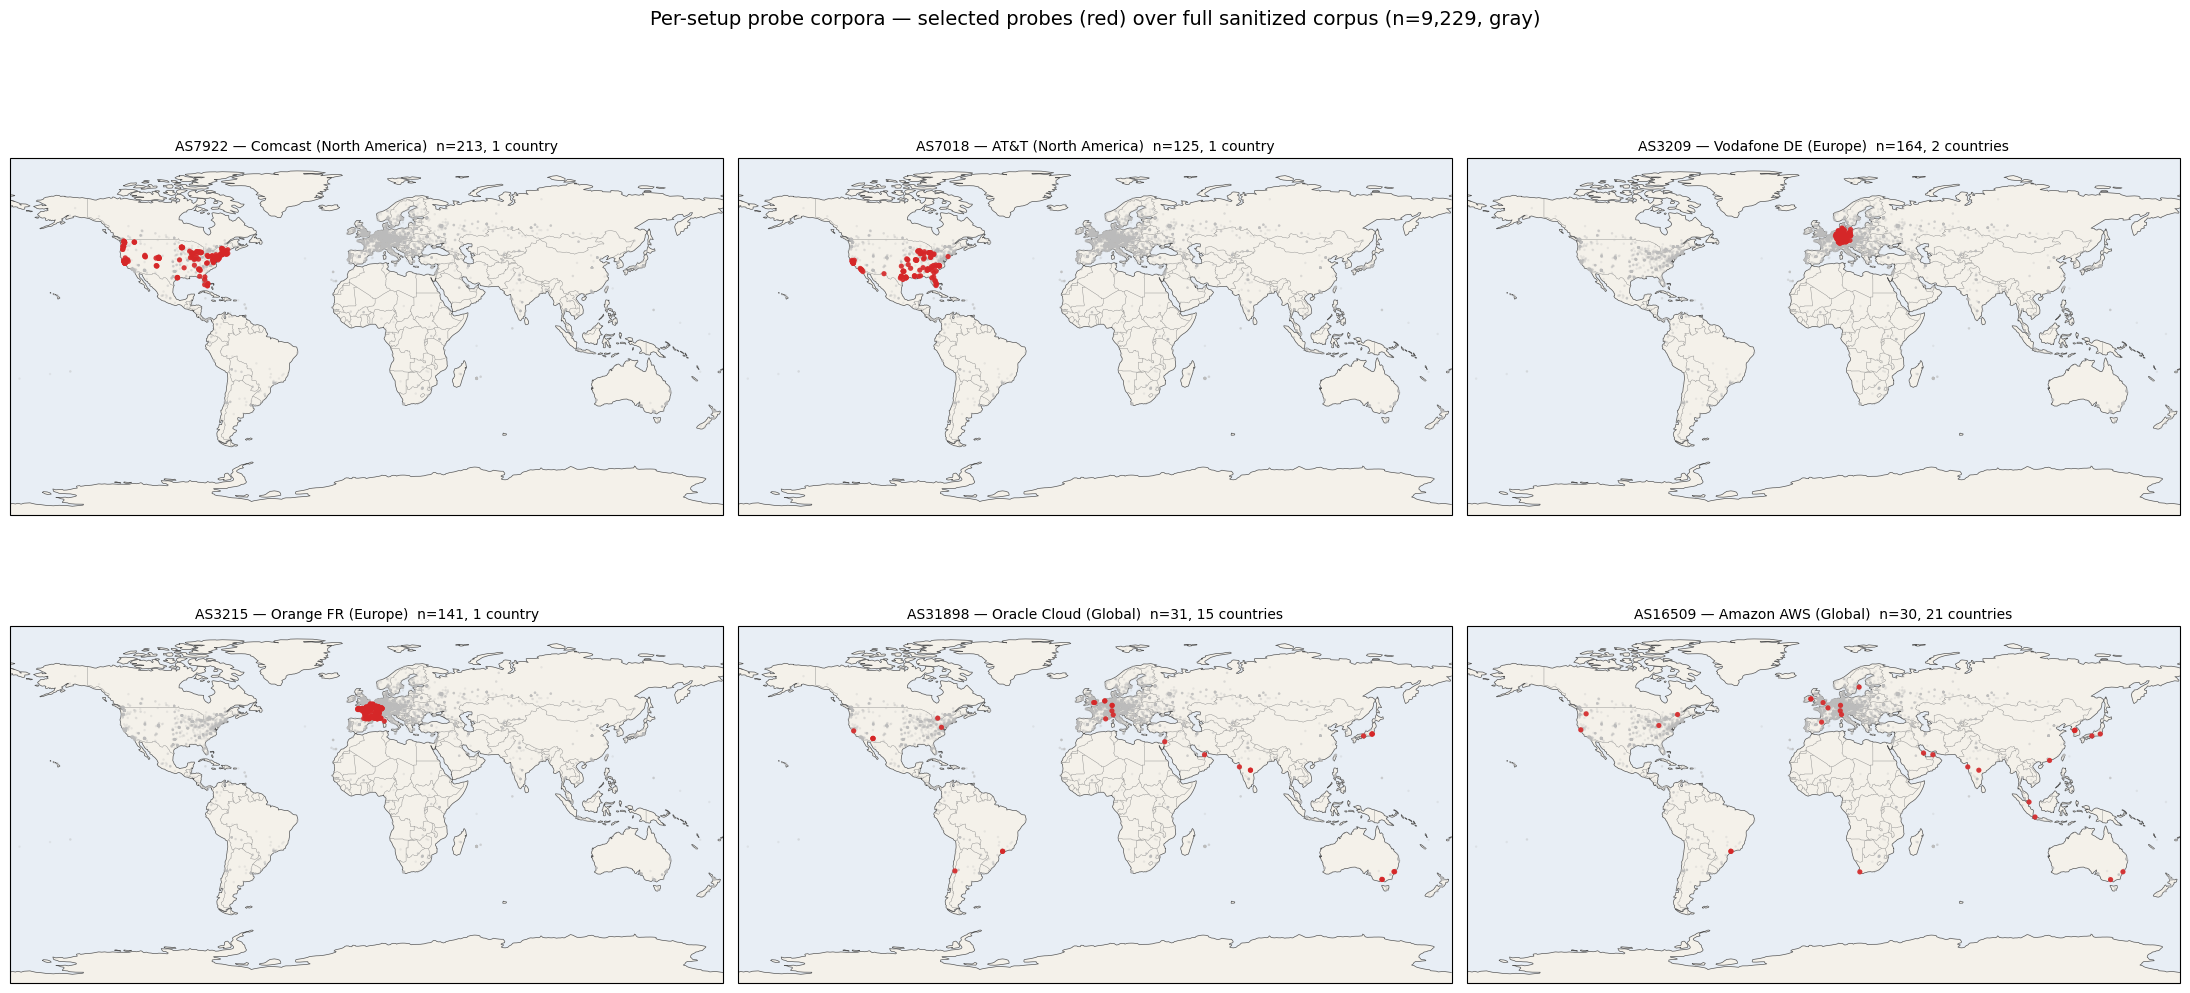

In [ ]:
# 2x3 grid of per-setup probe maps. Selected probes in red, full sanitized
# corpus underplotted in faint gray for context.
n_cols = 3
n_rows = 2
fig = plt.figure(figsize=(22, 11))

bg_lons = all_df["lon"].to_numpy()
bg_lats = all_df["lat"].to_numpy()

for i, (asn, operator, setup_continent, folder) in enumerate(SETUPS):
    info = per_setup_probes[asn]
    lons = [
        float((e.get("geometry") or {}).get("coordinates", [None, None])[0])
        for e in info["kept"]
        if (e.get("geometry") or {}).get("coordinates")
    ]
    lats = [
        float((e.get("geometry") or {}).get("coordinates", [None, None])[1])
        for e in info["kept"]
        if (e.get("geometry") or {}).get("coordinates")
    ]
    n_countries = info["stats"]["kept_by_country"]
    cw = "country" if len(n_countries) == 1 else "countries"
    ax = fig.add_subplot(n_rows, n_cols, i + 1, projection=ccrs.PlateCarree())
    plot_probes_on_map(
        ax,
        lons,
        lats,
        title=(
            f"AS{asn} — {operator} ({setup_continent})  "
            f"n={info['stats']['kept']}, {len(n_countries)} {cw}"
        ),
        color="#d62728",
        s=14,
        alpha=0.9,
        gridlines=False,
        background_lons=bg_lons,
        background_lats=bg_lats,
        title_fontsize=10,
    )

fig.suptitle(
    f"Per-setup probe corpora — selected probes (red) over full sanitized corpus (n={len(all_df):,}, gray)",
    fontsize=14,
    y=0.995,
)
plt.tight_layout()
plt.show()